In [1]:
%load_ext autoreload
%autoreload 2

import os
import numpy as np
import matplotlib.pyplot as plt

import torch
import torchdiffeq
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

## 生成轨迹数据

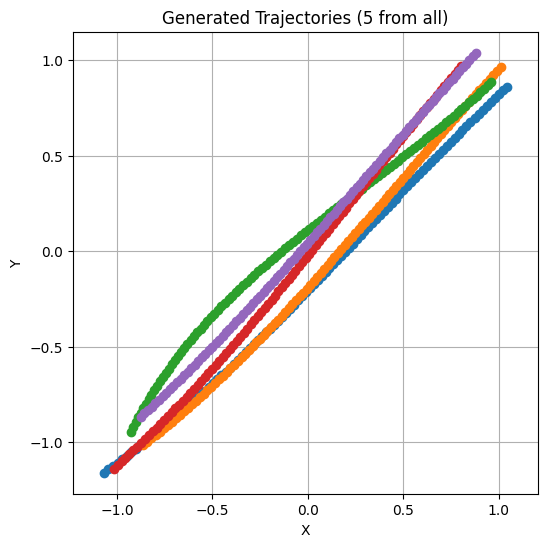

In [2]:
def sample_point_in_circle(center, radius):
    angle = np.random.uniform(0, 2 * np.pi)
    r = radius * np.sqrt(np.random.uniform(0, 1))
    return center + r * np.array([np.cos(angle), np.sin(angle)])

def generate_bezier_curve(P0, P1, P2, P3, num_points=100):
    t = np.linspace(0, 1, num_points).reshape(-1, 1)
    B_t = (1 - t)**3 * P0 + 3 * (1 - t)**2 * t * P1 + 3 * (1 - t) * t**2 * P2 + t**3 * P3
    return B_t

baseline_start = np.array([-1, -1])
baseline_end   = np.array([ 1,  1])
radius = 0.2

dominant_endpoint = "start"

if dominant_endpoint == "start":
    perturbation_scale_P1 = 0.7
    perturbation_scale_P2 = 0.01
elif dominant_endpoint == "end":
    perturbation_scale_P1 = 0.1
    perturbation_scale_P2 = 0.3
else:
    perturbation_scale_P1 = perturbation_scale_P2 = 0.2

num_trajectories = 8000
trajectories = []

for i in range(num_trajectories):
    P0 = sample_point_in_circle(baseline_start, radius)
    P3 = sample_point_in_circle(baseline_end, radius)
    
    base_vector = P3 - P0
    perp_vector = np.array([-base_vector[1], base_vector[0]])
    perp_vector = perp_vector / (np.linalg.norm(perp_vector) + 1e-8)
  
    P1 = P0 + base_vector / 3.0
    P2 = P0 + 2 * base_vector / 3.0
    
    P1 = P1 + np.random.uniform(-perturbation_scale_P1, perturbation_scale_P1) * perp_vector
    P2 = P2 + np.random.uniform(-perturbation_scale_P2, perturbation_scale_P2) * perp_vector
    
    curve = generate_bezier_curve(P0, P1, P2, P3, num_points=100)
    curve = curve.T
    trajectories.append(curve)

trajectories = np.array(trajectories)  # [8000, 2, 100]

num_plots = 5
indices = np.random.choice(len(trajectories), size=num_plots, replace=False)

plt.figure(figsize=(6, 6))
for idx in indices:
    traj = trajectories[idx]
    plt.plot(traj[0], traj[1], marker='o', linestyle='-')
plt.title("Generated Trajectories (5 from all)")
plt.xlabel("X")
plt.ylabel("Y")
plt.axis("equal")
plt.grid(True)
plt.show()

## 定义简化的 1D UNet 模型（最终修复版）

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from fmtorch.scheduler import CondOTScheduler
from fmtorch.path import AffinePath
from fmtorch.solver import ODESolver
from fmtorch.utils import ModelWrapper


class TrajectoryDataset(Dataset):
    def __init__(self, trajectories):
        self.trajectories = trajectories
        print(f"Dataset shape: {trajectories.shape}")  # [8000, 2, 100]

    def __len__(self):
        return len(self.trajectories)

    def __getitem__(self, idx):
        traj = self.trajectories[idx]  # [2, 100]
        return torch.tensor(traj, dtype=torch.float32)


class Mish(nn.Module):
    def forward(self, x):
        return x * torch.tanh(F.softplus(x))


class SinusoidalPosEmb(nn.Module):
    """时间步编码 - 修复版，支持标量和批次输入"""
    def __init__(self, dim):
        super().__init__()
        self.dim = dim # 时间步编码的维度 128

    def forward(self, t):
        device = t.device
        half_dim = self.dim // 2
        emb = torch.log(torch.tensor(10000.0)) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=device) * -emb)
        
        # 处理不同维度的时间输入
        if t.dim() == 0:  # 标量
            t = t.unsqueeze(0)
        if t.dim() == 1:  # (batch,)
            t = t.unsqueeze(-1)  # (batch, 1)
        
        emb = t * emb[None, :]  # (batch, half_dim)
        emb = torch.cat((emb.sin(), emb.cos()), dim=-1)  # (batch, dim)
        return emb


class ResBlock1D(nn.Module):
    """简化的1D残差块"""
    def __init__(self, channels, time_emb_dim):
        super().__init__()
        
        self.time_mlp = nn.Sequential(
            Mish(),
            nn.Linear(time_emb_dim, channels)
        )
        
        self.block = nn.Sequential(
            nn.GroupNorm(8, channels),
            Mish(),
            nn.Conv1d(channels, channels, 3, padding=1),
            nn.GroupNorm(8, channels),
            Mish(),
            nn.Conv1d(channels, channels, 3, padding=1),
        )
    
    def forward(self, x, t_emb):
        h = self.block(x)
        # 确保 t_emb 和 x 的 batch 维度匹配
        if t_emb.shape[0] == 1 and x.shape[0] > 1:
            t_emb = t_emb.expand(x.shape[0], -1)
        h = h + self.time_mlp(t_emb)[:, :, None]
        return x + h


class SimpleUNet1D(nn.Module):
    """
    简化的1D UNet - 最终修复版
    Input: (batch, 2, 100)
    Output: (batch, 2, 100)
    """
    def __init__(self, time_emb_dim=128, hidden_dim=128):
        super().__init__()
        
        self.time_emb_dim = time_emb_dim
        self.hidden_dim = hidden_dim
        
        # 时间嵌入
        self.time_mlp = nn.Sequential(
            SinusoidalPosEmb(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim * 4),
            Mish(),
            nn.Linear(time_emb_dim * 4, time_emb_dim)
        )
        
        # 编码器
        self.conv_in = nn.Conv1d(2, hidden_dim, 3, padding=1)
        
        # Level 1: 100 -> 100
        self.down1_block = nn.ModuleList([
            ResBlock1D(hidden_dim, time_emb_dim),
            ResBlock1D(hidden_dim, time_emb_dim)
        ])
        self.down1_sample = nn.Conv1d(hidden_dim, hidden_dim, 4, stride=2, padding=1)  # 100 -> 50
        
        # Level 2: 50 -> 50
        self.down2_block = nn.ModuleList([
            ResBlock1D(hidden_dim, time_emb_dim),
            ResBlock1D(hidden_dim, time_emb_dim)
        ])
        self.down2_sample = nn.Conv1d(hidden_dim, hidden_dim, 4, stride=2, padding=1)  # 50 -> 25
        
        # 中间层: 25
        self.mid_block = nn.ModuleList([
            ResBlock1D(hidden_dim, time_emb_dim),
            ResBlock1D(hidden_dim, time_emb_dim)
        ])
        
        # 解码器
        # Level 2: 25 -> 50
        self.up2_sample = nn.ConvTranspose1d(hidden_dim, hidden_dim, 4, stride=2, padding=1)
        self.up2_block = nn.ModuleList([
            ResBlock1D(hidden_dim * 2, time_emb_dim),
            ResBlock1D(hidden_dim * 2, time_emb_dim)
        ])
        self.up2_conv = nn.Conv1d(hidden_dim * 2, hidden_dim, 1)
        
        # Level 1: 50 -> 100
        self.up1_sample = nn.ConvTranspose1d(hidden_dim, hidden_dim, 4, stride=2, padding=1)
        self.up1_block = nn.ModuleList([
            ResBlock1D(hidden_dim * 2, time_emb_dim),
            ResBlock1D(hidden_dim * 2, time_emb_dim)
        ])
        self.up1_conv = nn.Conv1d(hidden_dim * 2, hidden_dim, 1)
        
        # 输出
        self.conv_out = nn.Sequential(
            nn.GroupNorm(8, hidden_dim),
            Mish(),
            nn.Conv1d(hidden_dim, 2, 3, padding=1)
        )
    
    def forward(self, x, t):
        """
        x: (batch, 2, 100)
        t: 可以是标量或 (batch,)
        """
        # 确保 t 至少是 1D，并且匹配 batch size
        if t.dim() == 0:  # 标量
            t = t.unsqueeze(0).expand(x.shape[0])
        elif t.shape[0] == 1 and x.shape[0] > 1:  # (1,) 但 batch > 1
            t = t.expand(x.shape[0])
        
        # 时间嵌入
        t_emb = self.time_mlp(t)  # (batch, time_emb_dim)
        
        # 编码器
        h = self.conv_in(x)  # (B, hidden_dim, 100)
        
        # Level 1
        h1 = h
        for block in self.down1_block:
            h1 = block(h1, t_emb)
        h1_pooled = self.down1_sample(h1)  # (B, hidden_dim, 50)
        
        # Level 2
        h2 = h1_pooled
        for block in self.down2_block:
            h2 = block(h2, t_emb)
        h2_pooled = self.down2_sample(h2)  # (B, hidden_dim, 25)
        
        # 中间层
        h_mid = h2_pooled
        for block in self.mid_block:
            h_mid = block(h_mid, t_emb)
        
        # 解码器
        # Level 2 上采样
        h = self.up2_sample(h_mid)  # (B, hidden_dim, 50)
        h = torch.cat([h, h2], dim=1)  # (B, hidden_dim*2, 50)
        for block in self.up2_block:
            h = block(h, t_emb)
        h = self.up2_conv(h)  # (B, hidden_dim, 50)
        
        # Level 1 上采样
        h = self.up1_sample(h)  # (B, hidden_dim, 100)
        h = torch.cat([h, h1], dim=1)  # (B, hidden_dim*2, 100)
        for block in self.up1_block:
            h = block(h, t_emb)
        h = self.up1_conv(h)  # (B, hidden_dim, 100)
        
        # 输出
        out = self.conv_out(h)  # (B, 2, 100)
        return out


class FlowMatchingModel1D(ModelWrapper):
    """Flow Matching 模型包装器"""
    def __init__(self, model):
        super().__init__(model)
        
    def forward(self, x: torch.Tensor, t: torch.Tensor, **extras):
        """
        x: (batch, 2, 100) 轨迹数据
        t: (batch, 1) 或 (batch,) 或标量
        """
        # 处理时间维度
        if t.dim() == 2:  # (batch, 1)
            t = t.squeeze(-1)  # (batch,)
        
        v_traj = self.model(x, t)
        return v_traj

ModuleNotFoundError: No module named 'fmtorch'

## 训练模型

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 创建简化的 1D UNet
unet_1d = SimpleUNet1D(
    time_emb_dim=128,
    hidden_dim=128
).to(device)

# 包装成 Flow Matching 模型
fm_model = FlowMatchingModel1D(unet_1d)

# 优化器
optimizer = torch.optim.AdamW(unet_1d.parameters(), lr=3e-4, weight_decay=0.01)

# Flow Matching 路径
path = AffinePath(scheduler=CondOTScheduler())

# 数据加载器
batch_size = 64
train_dataset = TrajectoryDataset(trajectories)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)

# 训练参数
n_epochs = 150
loss_history = []
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)

print(f"\nModel Architecture:")
print(f"Total parameters: {sum(p.numel() for p in unet_1d.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in unet_1d.parameters() if p.requires_grad):,}")

# 训练循环
print(f"\nStarting training for {n_epochs} epochs...\n")
for epoch in range(n_epochs):
    epoch_loss = 0.0
    num_batches = 0
    
    for batch_traj in train_loader:
        optimizer.zero_grad()
        
        # x1: 真实轨迹, x0: 噪声
        x1_traj = batch_traj.to(device)  # (batch, 2, 100)
        x0_traj = torch.randn_like(x1_traj)  # (batch, 2, 100)
        
        # 随机时间步
        t = torch.rand(x1_traj.shape[0]).to(device)  # (batch,)
        
        # Flow Matching 采样
        path_sample = path.sample(t=t, x_0=x0_traj, x_1=x1_traj)
        
        # 预测速度场
        vt_pred = fm_model(path_sample.x_t, path_sample.t)
        
        # Flow Matching 损失
        loss = torch.mean((vt_pred - path_sample.dx_t) ** 2)
        
        loss.backward()
        # 梯度裁剪
        torch.nn.utils.clip_grad_norm_(unet_1d.parameters(), 1.0)
        optimizer.step()
        
        epoch_loss += loss.item()
        num_batches += 1
        loss_history.append(loss.item())
    
    scheduler.step()
    avg_loss = epoch_loss / num_batches
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch + 1}/{n_epochs}, Avg Loss: {avg_loss:.6f}, LR: {scheduler.get_last_lr()[0]:.6f}")

print("\nTraining completed!")

## 可视化训练损失

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(loss_history, alpha=0.3, label='Raw Loss')
if len(loss_history) > 100:
    ma = np.convolve(loss_history, np.ones(100)/100, mode='valid')
    plt.plot(range(50, 50+len(ma)), ma, linewidth=2, label='Moving Average (100)')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 生成轨迹

In [ ]:
solver = ODESolver(velocity_model=fm_model)

# 生成初始噪声
num_samples = 8
with torch.no_grad():
    noise_trajs = torch.randn((num_samples, 2, 100), device=device)

# 可视化初始噪声
noise_trajs_np = noise_trajs.cpu().numpy()
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
for i in range(num_samples):
    plt.plot(noise_trajs_np[i, 0], noise_trajs_np[i, 1], 
             marker='o', markersize=2, alpha=0.6, linewidth=1)
plt.title("Initial Noise Trajectories", fontsize=14, fontweight='bold')
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True, alpha=0.3)
plt.axis("equal")

# 生成轨迹
time_grid = torch.tensor([0.0, 1.0], device=device)

print("Generating trajectories...")
with torch.no_grad():
    generated_trajs = solver.sample(
        x_init=noise_trajs,
        time_grid=time_grid,
        method='dopri5',
        step_size=None,
        atol=1e-4,
        rtol=1e-4,
        return_intermediates=False
    )

generated_trajs_np = generated_trajs.cpu().numpy()

plt.subplot(1, 2, 2)
for i in range(num_samples):
    plt.plot(generated_trajs_np[i, 0], generated_trajs_np[i, 1], 
             marker='o', markersize=2, alpha=0.6, linewidth=1.5)
plt.title("Generated Trajectories", fontsize=14, fontweight='bold')
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True, alpha=0.3)
plt.axis("equal")

plt.tight_layout()
plt.show()
print("Done!")

## 对比真实数据

In [ ]:
plt.figure(figsize=(18, 5))

# 真实轨迹
plt.subplot(1, 3, 1)
rand_indices = np.random.choice(trajectories.shape[0], size=8, replace=False)
for idx in rand_indices:
    plt.plot(trajectories[idx, 0], trajectories[idx, 1], 
             marker='o', markersize=2, linestyle='-', alpha=0.6, linewidth=1.5)
plt.title("Real Trajectories from Dataset", fontsize=14, fontweight='bold')
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True, alpha=0.3)
plt.axis("equal")

# 生成的轨迹
plt.subplot(1, 3, 2)
for i in range(num_samples):
    plt.plot(generated_trajs_np[i, 0], generated_trajs_np[i, 1], 
             marker='o', markersize=2, linestyle='-', alpha=0.6, linewidth=1.5)
plt.title("Generated Trajectories", fontsize=14, fontweight='bold')
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True, alpha=0.3)
plt.axis("equal")

# 叠加对比
plt.subplot(1, 3, 3)
for idx in rand_indices:
    plt.plot(trajectories[idx, 0], trajectories[idx, 1], 
             'b-', alpha=0.3, linewidth=2, label='Real' if idx == rand_indices[0] else '')
for i in range(num_samples):
    plt.plot(generated_trajs_np[i, 0], generated_trajs_np[i, 1], 
             'r-', alpha=0.5, linewidth=2, label='Generated' if i == 0 else '')
plt.title("Real vs Generated Comparison", fontsize=14, fontweight='bold')
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True, alpha=0.3)
plt.legend(loc='best')
plt.axis("equal")

plt.tight_layout()
plt.show()

## 生成更多样本进行评估

In [ ]:
# 生成更多轨迹
num_samples_large = 30
print(f"Generating {num_samples_large} trajectories...")
with torch.no_grad():
    noise_trajs_large = torch.randn((num_samples_large, 2, 100), device=device)
    generated_trajs_large = solver.sample(
        x_init=noise_trajs_large,
        time_grid=time_grid,
        method='dopri5',
        atol=1e-4,
        rtol=1e-4,
        return_intermediates=False
    )

generated_trajs_large_np = generated_trajs_large.cpu().numpy()

plt.figure(figsize=(14, 6))
for i in range(num_samples_large):
    plt.plot(generated_trajs_large_np[i, 0], generated_trajs_large_np[i, 1], 
             marker='o', markersize=1.5, linestyle='-', alpha=0.5, linewidth=1)
plt.title(f"Generated {num_samples_large} Trajectories", fontsize=14, fontweight='bold')
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True, alpha=0.3)
plt.axis("equal")
plt.show()
print("Done!")

## 模型总结

In [ ]:
print("="*60)
print("Model Summary")
print("="*60)
print(f"Architecture: Simplified 1D UNet")
print(f"Input shape: (batch, 2, 100)")
print(f"Output shape: (batch, 2, 100)")
print(f"Hidden dimensions: {unet_1d.hidden_dim}")
print(f"Time embedding dim: {unet_1d.time_emb_dim}")
print(f"Total parameters: {sum(p.numel() for p in unet_1d.parameters()):,}")
print(f"\nTraining:")
print(f"  - Epochs: {n_epochs}")
print(f"  - Batch size: {batch_size}")
print(f"  - Final loss: {loss_history[-1]:.6f}")
print(f"  - Average loss (last 100 steps): {np.mean(loss_history[-100:]):.6f}")
print("="*60)